In [82]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [83]:
words = open('names.txt', 'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [84]:
len(words)

32033

In [85]:
from string import ascii_lowercase
stoi = {s: i+1 for i, s in enumerate(ascii_lowercase)}
stoi['$'] = 0

itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)

In [86]:
block_size = 8

def build_dataset(words):
    X, y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '$':
            ix = stoi[ch]
            X.append(context)
            y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    y = torch.tensor(y)
    print(X.shape, y.shape)
    return X, y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

X_train, y_train = build_dataset(words[:n1])
X_valid, y_valid = build_dataset(words[n1:n2])
X_test, y_test = build_dataset(words[n2:])

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [87]:
for x, y in zip(X_train[:5], y_train[:5]):
    print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

$$$$$$$$ --> y
$$$$$$$y --> u
$$$$$$yu --> h
$$$$$yuh --> e
$$$$yuhe --> n


In [88]:
g = torch.Generator().manual_seed(2147483647)

class Sequential:
    def __init__(self, layers):
        self.layers = layers
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    
class Embedding:
    def __init__(self, num_embeddings, embeddings_dim):
        self.weight = torch.randn((num_embeddings, embeddings_dim))
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    def parameters(self):
        return [self.weight]

class FlattenNConsecutive:
    def __init__(self, n_ele):
        self.n_ele = n_ele
    def __call__(self, x):
        B, T, C = x.shape
        # self.out = x.view(B, -1, self.n_ele*C)
        x = x.view(B, T//self.n_ele, self.n_ele*C)
        if x.shape[1] == 1:
            x = x.squeeze(dim=1)
        self.out = x
        return self.out
    def parameters(self):
        return []

class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / (fan_in ** 0.5)
        self.bias = torch.zeros(fan_out) if bias else None
    def __call__(self, X):
        self.out = X @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    def parameters(self):
        return [self.weight] + ([self.bias] if self.bias is not None else [])

class BatchNorm1D: 
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # Parameters - training with Backpropogation
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers - trained with a running 'momentum update'
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    def __call__(self, X):
        # Forward Pass
        if self.training:
            if X.ndim == 2:
                dim = 0
            elif X.ndim == 3:
                dim = (0, 1)
            X_mean = X.mean(dim, keepdim=True) # Batch Mean
            X_var = X.var(dim, keepdim=True, unbiased=False) # Batch Variance
            # Update Buffers
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * X_mean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * X_var
        else:
            X_mean = self.running_mean
            X_var = self.running_var
        X_hat = (X - X_mean) / torch.sqrt(X_var + self.eps)
        self.out = self.gamma * X_hat + self.beta
        return self.out
    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, X):
        self.out = torch.tanh(X)
        return self.out
    def parameters(self):
        return []

In [89]:
torch.manual_seed(42)

In [90]:
n_emb = 24
n_hidden = 128

model = Sequential([
    Embedding(vocab_size, n_emb),
    FlattenNConsecutive(2), Linear(n_emb * 2, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
    FlattenNConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
    FlattenNConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1D(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])
with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

76579


In [91]:
e = torch.randn(4, 8, 24)
e[:, ::2, :].shape, e[:, 1::2, :].shape
explicit = torch.cat([e[:, ::2, :], e[:, 1::2, :]], dim=2)

(e.view(4, 4, 48) == explicit).all()

print(e.view(4, -1, 2*n_emb).shape)
print(e.view(4, -1, 4*n_emb).shape)

# (4, 4, 20) @ (20, 200) => (4, 4, 200)

torch.Size([4, 4, 48])
torch.Size([4, 2, 96])


In [92]:
ix = torch.randint(0, X_train.shape[0], (4, ))
Xb, yb = X_train[ix], y_train[ix]
logits = model(Xb)
Xb.shape, logits.shape

(torch.Size([4, 8]), torch.Size([4, 27]))

In [93]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', layer.out.shape)

Embedding : torch.Size([4, 8, 24])
FlattenNConsecutive : torch.Size([4, 4, 48])
Linear : torch.Size([4, 4, 128])
BatchNorm1D : torch.Size([4, 4, 128])
Tanh : torch.Size([4, 4, 128])
FlattenNConsecutive : torch.Size([4, 2, 256])
Linear : torch.Size([4, 2, 128])
BatchNorm1D : torch.Size([4, 2, 128])
Tanh : torch.Size([4, 2, 128])
FlattenNConsecutive : torch.Size([4, 256])
Linear : torch.Size([4, 128])
BatchNorm1D : torch.Size([4, 128])
Tanh : torch.Size([4, 128])
Linear : torch.Size([4, 27])


In [94]:
max_steps = 200000
batch_size = 32
lossi = []
for epoch in range(max_steps):
    # Mini Batch Construct
    ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
    X_batch, y_batch = X_train[ix], y_train[ix]
    # Forward Pass
    logits = model(X_batch)
    loss = F.cross_entropy(logits, y_batch)
    # Backward Pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # Update Step
    lr = 0.1 if epoch < 150000 else 0.01 # Step Learning Rate Decay
    for p in parameters:
        p.data += -lr * p.grad 
    # Track Stats
    if epoch % 10000 == 0:
        print(f'{epoch:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    # break

      0/ 200000: 3.2974
  10000/ 200000: 1.7998
  20000/ 200000: 1.8631
  30000/ 200000: 2.0131
  40000/ 200000: 1.9992
  50000/ 200000: 2.0476
  60000/ 200000: 2.2628
  70000/ 200000: 1.5901
  80000/ 200000: 1.8099
  90000/ 200000: 2.3632
 100000/ 200000: 2.4812
 110000/ 200000: 1.5426
 120000/ 200000: 1.7990
 130000/ 200000: 2.2185
 140000/ 200000: 1.6466
 150000/ 200000: 2.1010
 160000/ 200000: 1.7959
 170000/ 200000: 1.8028
 180000/ 200000: 2.6957
 190000/ 200000: 1.3945


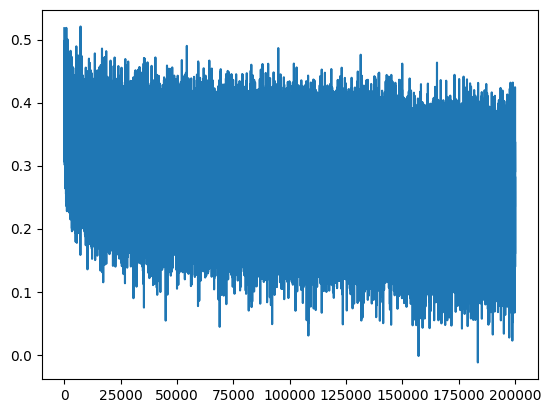

In [95]:
plt.plot(lossi)

In [96]:
len(lossi), lossi[0], torch.tensor(3.2991).log10().item()

(200000, 0.5181674957275391, 0.5183954834938049)

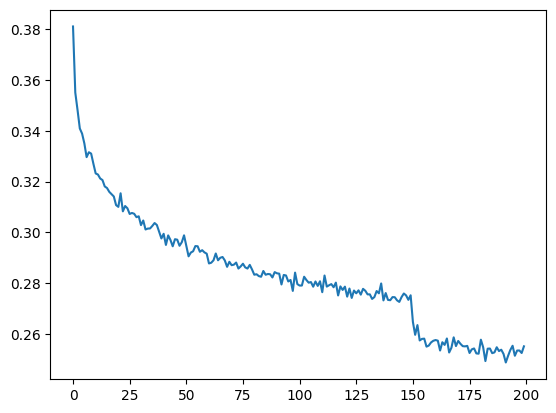

In [97]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [98]:
for layer in model.layers:
    layer.training = False # BatchNorm1D so that we can go into eval mode

In [99]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (X_train, y_train),
        'valid': (X_valid, y_valid),
        'test': (X_test, y_test),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('valid')

train 1.7671676874160767
valid 1.9882044792175293


In [101]:
# Sample from the Model
g = torch.Generator().manual_seed(2147483647)
for _ in range(10):
    out = []
    context = [0] * block_size
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        out.append(ix)
        context = context[1:] + [ix]
        if ix == 0:
            break
    print(''.join(itos[x] for x in out[:-1]))

dexber
jalius
roczie
harlin
milea
nyland
zakiah
samiyah
javery
mari
